# Notebook 02: Baseline Similarity
**Ship of Theseus NLP Project**

Compute and visualize lexical (BLEU, ROUGE-L) and semantic (BERTScore) similarity
between T0 and T1/T2/T3 across all 7 paraphrasers.

**Prerequisites:**
- `python -m src.data.prepare_corpus`
- Notebook 01 (data exploration) for context
- If no local GPU: use the Colab section below to compute metrics

## 1. Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import (
    ALL_DATASETS, PARAPHRASERS, PARAPHRASER_FAMILIES,
    TIER_PALETTE, PARAPHRASER_PALETTE,
    FIGURES_DIR, EXPERIMENTS_DIR, DATA_PROCESSED,
)
from src.data.load_data import get_paired_texts

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.2)

corpus = pd.read_parquet(DATA_PROCESSED / "corpus_full.parquet")
print(f"Corpus: {len(corpus):,} rows")

Corpus: 66,400 rows


## 2. Similarity Metrics

| Metric | Type | What it measures |
|--------|------|------------------|
| BLEU | Lexical | N-gram precision overlap |
| ROUGE-L | Lexical | Longest common subsequence |
| BERTScore | Semantic | Contextual embedding similarity |

**BLEU and ROUGE are lexical only.** They do not measure meaning preservation.

### GPU check

In [2]:
import torch

HAS_GPU = torch.cuda.is_available()
print(f"CUDA available: {HAS_GPU}")

if HAS_GPU:
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB")
    print("\n-> Running all metrics locally.")
else:
    print("\n-> No GPU detected. BERTScore will be too slow locally.")
    print("   Run the Colab section below, then skip to 'Load precomputed results'.")

CUDA available: False

-> No GPU detected. BERTScore will be too slow locally.
   Run the Colab section below, then skip to 'Load precomputed results'.


---
### Option A: Compute locally (GPU available)
Skip this cell if no GPU.

In [3]:
if not HAS_GPU:
    raise RuntimeError("No GPU. Skip to Option B.")

from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bertscore_fn

smoother = SmoothingFunction().method1
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def compute_bleu(ref, hyp):
    r, h = ref.lower().split(), hyp.lower().split()
    if not r or not h: return 0.0
    try: return sentence_bleu([r], h, smoothing_function=smoother)
    except: return 0.0

def compute_rouge_l(ref, hyp):
    try: return rouge.score(ref, hyp)["rougeL"].fmeasure
    except: return 0.0

def compute_bertscore_batch(references, hypotheses):
    P, R, F1 = bertscore_fn(
        hypotheses, references,
        lang="en", verbose=True, batch_size=64, device="cuda",
    )
    return F1.tolist()

results = []
for pkey, pinfo in PARAPHRASERS.items():
    pname = pinfo["name"]
    print(f"\n{pname}...")
    paired = get_paired_texts(corpus, paraphraser_key=pkey)
    if len(paired) == 0: continue

    for tier in ["T1", "T2", "T3"]:
        if tier not in paired.columns: continue
        valid = paired.dropna(subset=["T0", tier])
        if len(valid) == 0: continue
        refs, hyps = valid["T0"].tolist(), valid[tier].tolist()

        bleus = [compute_bleu(r, h) for r, h in
                 tqdm(zip(refs, hyps), total=len(refs), desc=f"  BLEU {tier}")]
        rouges = [compute_rouge_l(r, h) for r, h in
                  tqdm(zip(refs, hyps), total=len(refs), desc=f"  ROUGE {tier}")]
        print(f"  BERTScore {tier} ({len(refs)} pairs)...")
        berts = compute_bertscore_batch(refs, hyps)

        results.append({
            "Paraphraser": pname, "Paraphraser_Key": pkey, "Tier": tier,
            "BLEU": np.mean(bleus), "BLEU_std": np.std(bleus),
            "ROUGE-L": np.mean(rouges), "ROUGE-L_std": np.std(rouges),
            "BERTScore": np.mean(berts), "BERTScore_std": np.std(berts),
            "n_samples": len(refs),
        })
        print(f"  {tier}: BLEU={np.mean(bleus):.4f}  "
              f"ROUGE-L={np.mean(rouges):.4f}  BERTScore={np.mean(berts):.4f}")

baseline_df = pd.DataFrame(results)
(EXPERIMENTS_DIR / "baseline_results").mkdir(parents=True, exist_ok=True)
baseline_df.to_csv(
    EXPERIMENTS_DIR / "baseline_results" / "similarity_baselines.csv", index=False
)
print("\nSaved to experiments/baseline_results/similarity_baselines.csv")

RuntimeError: No GPU. Skip to Option B.

---
### Option B: Compute on Google Colab (no local GPU)

1. Upload `data/processed/corpus_full.parquet` to Google Drive
2. Open a new Colab notebook: **Runtime > Change runtime type > T4 GPU**
3. Paste and run the code below in Colab
4. Download `similarity_baselines.csv` from Drive
5. Place it in `experiments/baseline_results/`
6. Continue to **"Load precomputed results"** below

```python
# ---- Run this in Google Colab ----
!pip install -q bert-score rouge-score nltk pyarrow

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd, numpy as np, torch
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from bert_score import score as bertscore_fn

print(f"GPU: {torch.cuda.get_device_name(0)}")

corpus = pd.read_parquet('/content/drive/MyDrive/corpus_full.parquet')

PARAPHRASERS = [
    "chatgpt", "palm", "dipper", "dipper(low)",
    "dipper(high)", "pegasus(full)", "pegasus(slight)",
]
NAMES = {
    "chatgpt": "ChatGPT", "palm": "PaLM2",
    "dipper": "Dipper", "dipper(low)": "Dipper (Low)",
    "dipper(high)": "Dipper (High)",
    "pegasus(full)": "Pegasus (Full)",
    "pegasus(slight)": "Pegasus (Slight)",
}

smoother = SmoothingFunction().method1
rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)

def bleu(ref, hyp):
    r, h = ref.lower().split(), hyp.lower().split()
    if not r or not h: return 0.0
    try: return sentence_bleu([r], h, smoothing_function=smoother)
    except: return 0.0

def rouge_l(ref, hyp):
    try: return rouge.score(ref, hyp)["rougeL"].fmeasure
    except: return 0.0

results = []
for pkey in PARAPHRASERS:
    pname = NAMES[pkey]
    print(f"\n{pname}...")
    mask = (corpus["paraphraser"] == pkey) | (corpus["tier"] == "T0")
    pivoted = corpus[mask].pivot_table(
        index=["key", "source"], columns="tier",
        values="text", aggfunc="first"
    ).reset_index().dropna(subset=["T0"])

    for tier in ["T1", "T2", "T3"]:
        if tier not in pivoted.columns: continue
        valid = pivoted.dropna(subset=["T0", tier])
        if len(valid) == 0: continue
        refs, hyps = valid["T0"].tolist(), valid[tier].tolist()

        bleus = [bleu(r, h) for r, h in tqdm(zip(refs, hyps), total=len(refs))]
        rouges = [rouge_l(r, h) for r, h in tqdm(zip(refs, hyps), total=len(refs))]
        P, R, F1 = bertscore_fn(hyps, refs, lang="en", verbose=True,
                                batch_size=64, device="cuda")
        berts = F1.tolist()

        results.append({
            "Paraphraser": pname, "Paraphraser_Key": pkey, "Tier": tier,
            "BLEU": np.mean(bleus), "BLEU_std": np.std(bleus),
            "ROUGE-L": np.mean(rouges), "ROUGE-L_std": np.std(rouges),
            "BERTScore": np.mean(berts), "BERTScore_std": np.std(berts),
            "n_samples": len(refs),
        })
        print(f"  {tier}: BLEU={np.mean(bleus):.4f}  "
              f"ROUGE-L={np.mean(rouges):.4f}  BERTScore={np.mean(berts):.4f}")

pd.DataFrame(results).to_csv(
    '/content/drive/MyDrive/similarity_baselines.csv', index=False
)
print("\nSaved. Download and place in experiments/baseline_results/")
```

---
### Load precomputed results
Both paths produce the same CSV. Load it here.

In [4]:
baseline_path = EXPERIMENTS_DIR / "baseline_results" / "similarity_baselines.csv"

if "baseline_df" not in dir() or baseline_df is None:
    baseline_df = pd.read_csv(baseline_path)
    print(f"Loaded from {baseline_path}")
else:
    print("Using results computed locally above.")

print(f"{len(baseline_df)} rows: {baseline_df['Paraphraser'].nunique()} paraphrasers x "
      f"{baseline_df['Tier'].nunique()} tiers")

Loaded from C:\Users\rjjos\Documents\NEU\Courses\Sem-2\NLP\ShipOfTheseus-NLP\experiments\baseline_results\similarity_baselines.csv
21 rows: 7 paraphrasers x 3 tiers


## 3. Baseline Table

In [5]:
for metric in ["BLEU", "ROUGE-L", "BERTScore"]:
    print(f"\n{metric}:")
    pivot = baseline_df.pivot_table(
        index="Paraphraser", columns="Tier", values=metric,
    ).reindex(columns=["T1", "T2", "T3"])
    print(pivot.round(4).to_string())


BLEU:
Tier                  T1      T2      T3
Paraphraser                             
ChatGPT           0.1953  0.1717  0.1428
Dipper            0.1683  0.0925  0.0613
Dipper (High)     0.0097  0.0041  0.0024
Dipper (Low)      0.4923  0.3694  0.3036
PaLM2             0.4701  0.3825  0.3375
Pegasus (Full)    0.4146  0.2973  0.2517
Pegasus (Slight)  0.8413  0.7283  0.6381

ROUGE-L:
Tier                  T1      T2      T3
Paraphraser                             
ChatGPT           0.5025  0.4641  0.4257
Dipper            0.3773  0.3170  0.2570
Dipper (High)     0.1301  0.1068  0.0912
Dipper (Low)      0.7157  0.6277  0.5646
PaLM2             0.6978  0.6253  0.5841
Pegasus (Full)    0.6734  0.5878  0.5404
Pegasus (Slight)  0.9187  0.8571  0.8043

BERTScore:
Tier                  T1      T2      T3
Paraphraser                             
ChatGPT           0.9225  0.9145  0.9071
Dipper            0.9045  0.8883  0.8770
Dipper (High)     0.8059  0.8036  0.8033
Dipper (Low)      0.9530  0.

## 4. Linguistic Delta: Style vs Content Decay

Core hypothesis: lexical metrics (BLEU, ROUGE) decay faster than semantic metrics (BERTScore).
The "planks" (words, style) get replaced while the "hull" (meaning) stays intact.

### Per-family decay curves

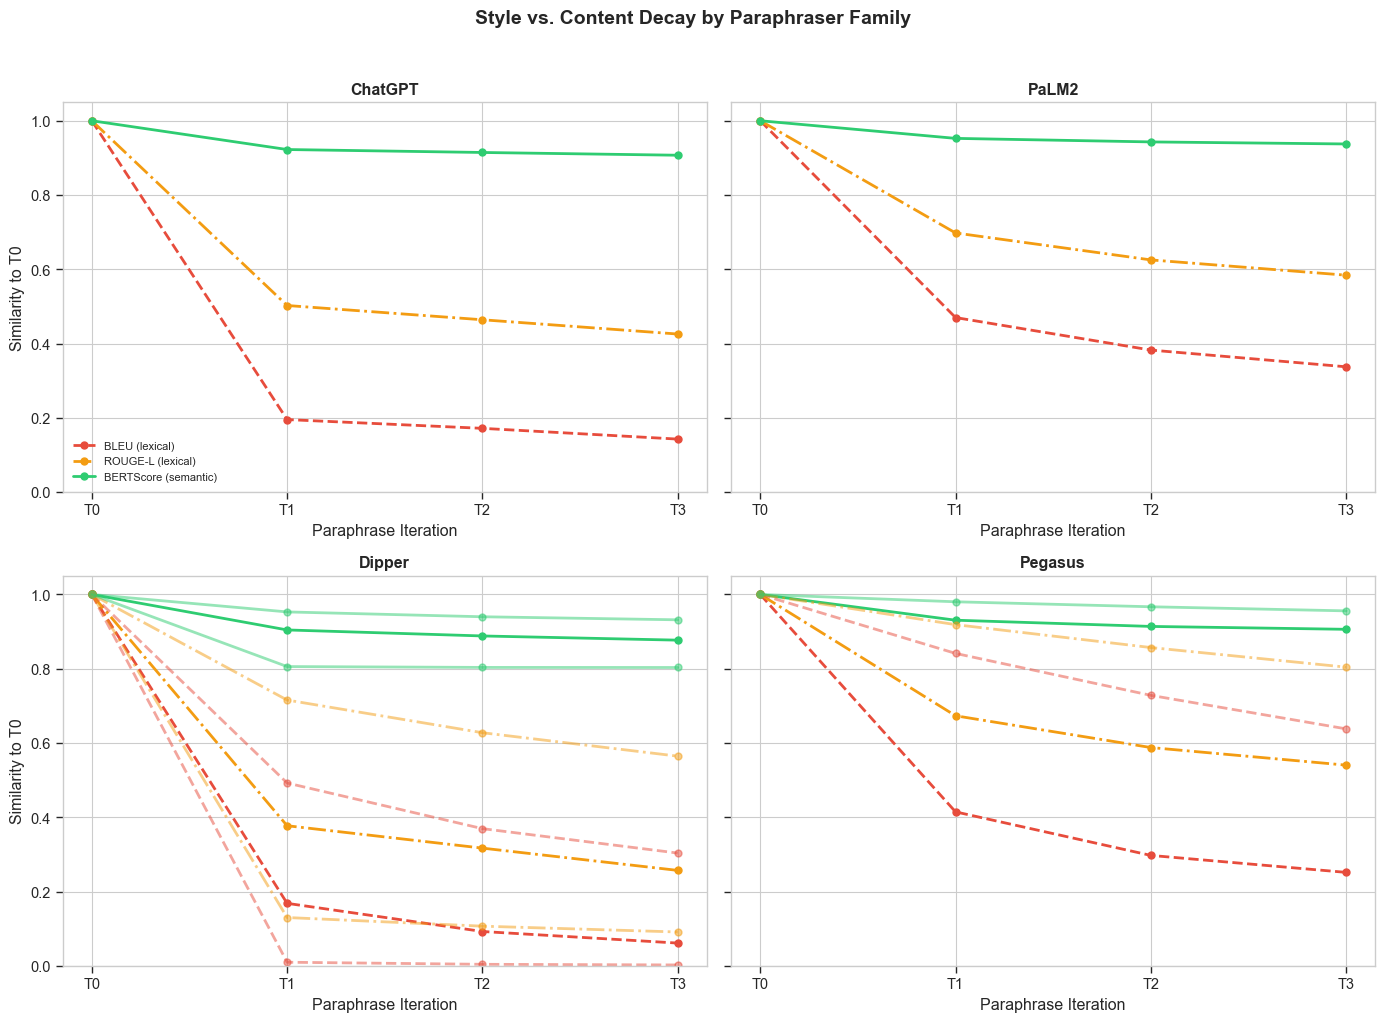

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
fig.suptitle("Style vs. Content Decay by Paraphraser Family",
             fontsize=14, fontweight="bold", y=1.02)

for idx, (family, keys) in enumerate(PARAPHRASER_FAMILIES.items()):
    ax = axes[idx // 2][idx % 2]

    for pkey in keys:
        pdata = baseline_df[baseline_df["Paraphraser_Key"] == pkey].sort_values("Tier")
        if len(pdata) == 0: continue
        tn = [int(t[1]) for t in pdata["Tier"]]

        for metric, ls, color, label in [
            ("BLEU", "--", "#e74c3c", "BLEU (lexical)"),
            ("ROUGE-L", "-.", "#f39c12", "ROUGE-L (lexical)"),
            ("BERTScore", "-", "#2ecc71", "BERTScore (semantic)"),
        ]:
            vals = [1.0] + pdata[metric].tolist()
            lbl = label if pkey == keys[0] else None
            alpha = 1.0 if pkey == keys[0] else 0.5
            ax.plot([0]+tn, vals, ls, color=color, marker="o",
                    linewidth=2, markersize=5, label=lbl, alpha=alpha)

    ax.set_title(family, fontweight="bold")
    ax.set_xlabel("Paraphrase Iteration")
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(["T0", "T1", "T2", "T3"])
    ax.set_ylim(0, 1.05)
    if idx % 2 == 0: ax.set_ylabel("Similarity to T0")
    if idx == 0: ax.legend(fontsize=8, loc="lower left")

plt.tight_layout()
(FIGURES_DIR / "decay_curves").mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "decay_curves" / "linguistic_delta_by_family.png",
            dpi=150, bbox_inches="tight")
plt.show()

### Aggregate decay (all paraphrasers averaged)

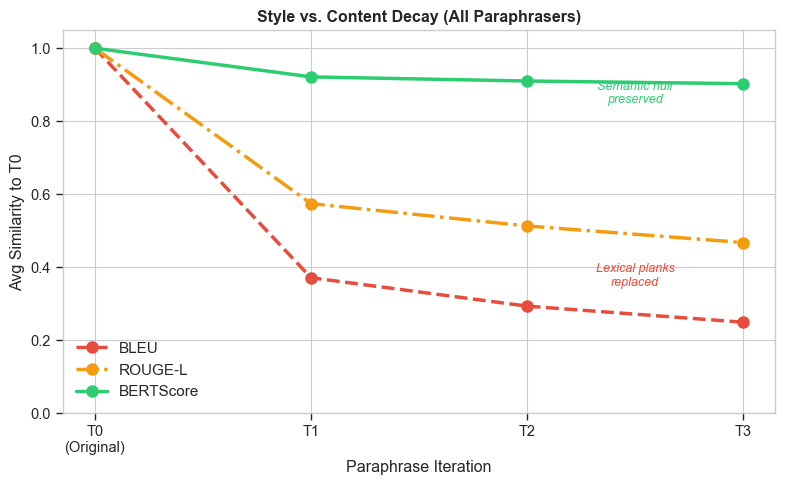

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

for metric, ls, color in [
    ("BLEU", "--", "#e74c3c"),
    ("ROUGE-L", "-.", "#f39c12"),
    ("BERTScore", "-", "#2ecc71"),
]:
    avg = baseline_df.groupby("Tier")[metric].mean()
    tn = [int(t[1]) for t in avg.index]
    ax.plot([0]+tn, [1.0]+avg.tolist(), ls, color=color,
            marker="o", linewidth=2.5, markersize=8, label=metric)

ax.set_xlabel("Paraphrase Iteration")
ax.set_ylabel("Avg Similarity to T0")
ax.set_title("Style vs. Content Decay (All Paraphrasers)", fontweight="bold")
ax.set_xticks([0, 1, 2, 3])
ax.set_xticklabels(["T0\n(Original)", "T1", "T2", "T3"])
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.annotate("Semantic hull\npreserved", xy=(2.5, 0.85),
            fontsize=9, color="#2ecc71", ha="center", style="italic")
ax.annotate("Lexical planks\nreplaced", xy=(2.5, 0.35),
            fontsize=9, color="#e74c3c", ha="center", style="italic")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "decay_curves" / "aggregate_style_vs_content.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 5. Key Observations

**Hypothesis confirmed:** BERTScore stays 0.80-0.98 across all tiers and paraphrasers while BLEU drops as low as 0.002 (Dipper High at T1). The semantic hull is preserved; the lexical planks are replaced.
    
**Sharpest decay at T1:** For ChatGPT, BLEU drops 81% at the first iteration (1.0 to 0.20), then only falls to 0.14 by T3. The first paraphrase does most of the damage.
    
**Paraphraser aggressiveness ranking** (most conservative to most aggressive):
Pegasus (Slight) > Dipper (Low) ~ PaLM2 > Pegasus (Full) > ChatGPT > Dipper > Dipper (High)
    
This ranking is consistent across all three metrics.
    
**RQ3 signal (paraphraser fingerprints):** The Dipper family shows massive internal spread. Dipper (High) BLEU at T1 = 0.010, while Dipper (Low) = 0.492. Same model, different settings, completely different decay signature. The gap between Dipper variants is wider than between entirely different model families. Strong evidence that paraphraser configuration leaves identifiable traces.
    
**Notable numbers:**
- Dipper (High) at T3: BLEU = 0.002, ROUGE-L = 0.091, BERTScore = 0.803. Virtually zero lexical overlap, yet 80% semantic preservation.
- Pegasus (Slight) at T3: BLEU = 0.638, ROUGE-L = 0.804, BERTScore = 0.956. Barely touched.
- The BERTScore floor across all paraphrasers is ~0.80, suggesting a natural limit to how much meaning can be preserved when all words are replaced.

In [8]:
print(f"Done. Results in experiments/baseline_results/, figures in figures/decay_curves/")

Done. Results in experiments/baseline_results/, figures in figures/decay_curves/
